<a href="https://colab.research.google.com/github/aisha-partha/AIMLOps-MiniProjects/blob/mp6/M5_NB_MiniProject_1_ResumeClassification_Using_Bert_Aishwarya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Programme in AI and MLOps
## A programme by IISc and TalentSprint
### Mini-Project 1: Resume Classification

## Learning Objectives

At the end of the mini-project, you will be able to :

* perform data preprocessing, EDA on the resume dataset
* fine-tune Bert model for resume classification

## Dataset Description

The data is in CSV format, with two features: Category, and Resume.

**Category** -  Industry sector to which the resume belongs to, and

**Resume** - The complete CV (text) of the candidate.

##  Grading = 10 Points

## Information

Companies often receive thousands of resumes for each job posting and employ dedicated screening officers to screen qualified candidates. Finding suitable candidates for an open role from a database of 1000s of resumes can be a tough task. Automated resume categorization can speeden the candidate selection process. Such automation can really ease the tedious process of fair screening and shortlisting the right candidates and aid quick decisionmaking.

To learn more about this, click [here](https://www.sciencedirect.com/science/article/pii/S187705092030750X).

**Problem Statement:** Fine-tune a pre-trained Bert model for resume classification.

*For fine-tuning Bert, refer to the demo session on 'HuggingFace platform' held on 17 Aug.*

### Install dependencies

After installing the below dependencies ***Restart the session/runtime***.

In [1]:
!pip -q uninstall pyarrow -y
!pip -q install pyarrow==15.0.2
!pip -q install datasets
!pip -q install accelerate
!pip -q install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.3/38.3 MB 19.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, but you have pyarrow 15.0.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 12.1 MB/s eta 0:00:00


### <font color="#990000">Restart Session/Runtime</font>

### Import required packages

In [2]:
from datasets import Dataset, DatasetDict

from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
from transformers import Trainer
from transformers import pipeline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


### Downloading the data

In [3]:
#@title Download the data
!wget -qq https://cdn.iisc.talentsprint.com/CDS/Datasets/UpdatedResumeDataSet.csv
!ls | grep '.csv'

UpdatedResumeDataSet.csv


**Exercise 1: Read the UpdatedResumeDataset.csv dataset [0.5 Mark]**

**Hint:** pd.read_csv( , encoding='utf-8')

In [4]:
# Read the dataset
# YOUR CODE HERE
df = pd.read_csv('UpdatedResumeDataSet.csv', encoding='utf-8')

### Pre-processing and EDA

**Exercise 2: Display  all the categories of resumes and their counts in the dataset [0.5 Mark]**



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


In [6]:
# Display the distinct categories of resume
# YOUR CODE HERE
df['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

In [7]:
# Displaying the number of distinct categories of resume
# YOUR CODE HERE
len(df['Category'].unique())

25

In [8]:
# Display the distinct categories of resume and the number of records belonging to each category
# YOUR CODE HERE
df['Category'].value_counts()

,count
Category,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
Sales,40
Data Science,40


**Exercise 3: Create the count plot of different categories [0.5 Mark]**

**Hint:** Use `sns.countplot()`

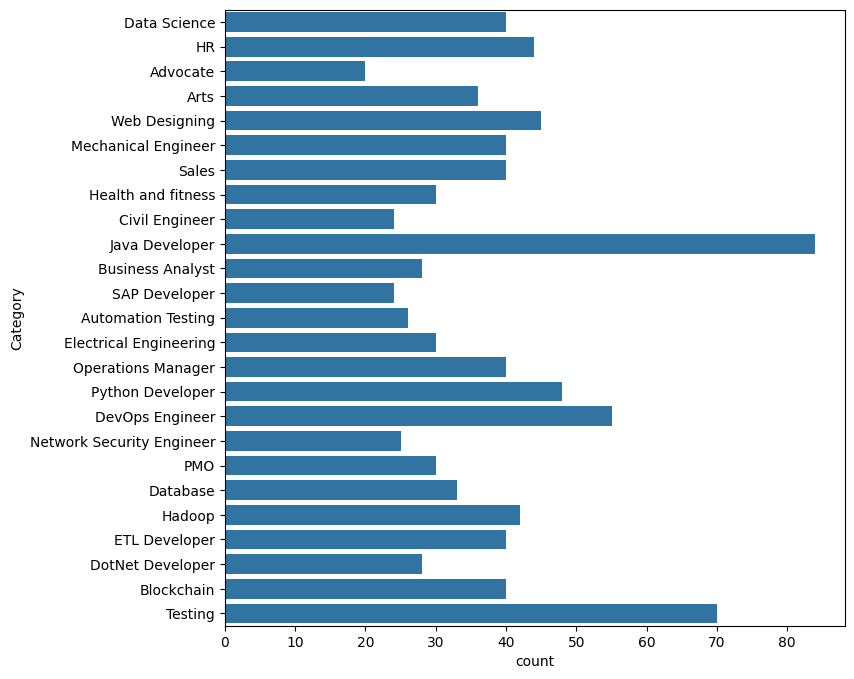

In [9]:
# YOUR CODE HERE
plt.figure(figsize= (8, 8))
sns.countplot(y= 'Category', data= df)
plt.show()

**Exercise 4: Create a pie plot depicting the percentage of resume distributions category-wise. [0.5 mark]**

**Hint:** Use [plt.pie()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html) and [plt.get_cmap](https://matplotlib.org/stable/tutorials/colors/colormaps.html) for color mapping the pie chart.

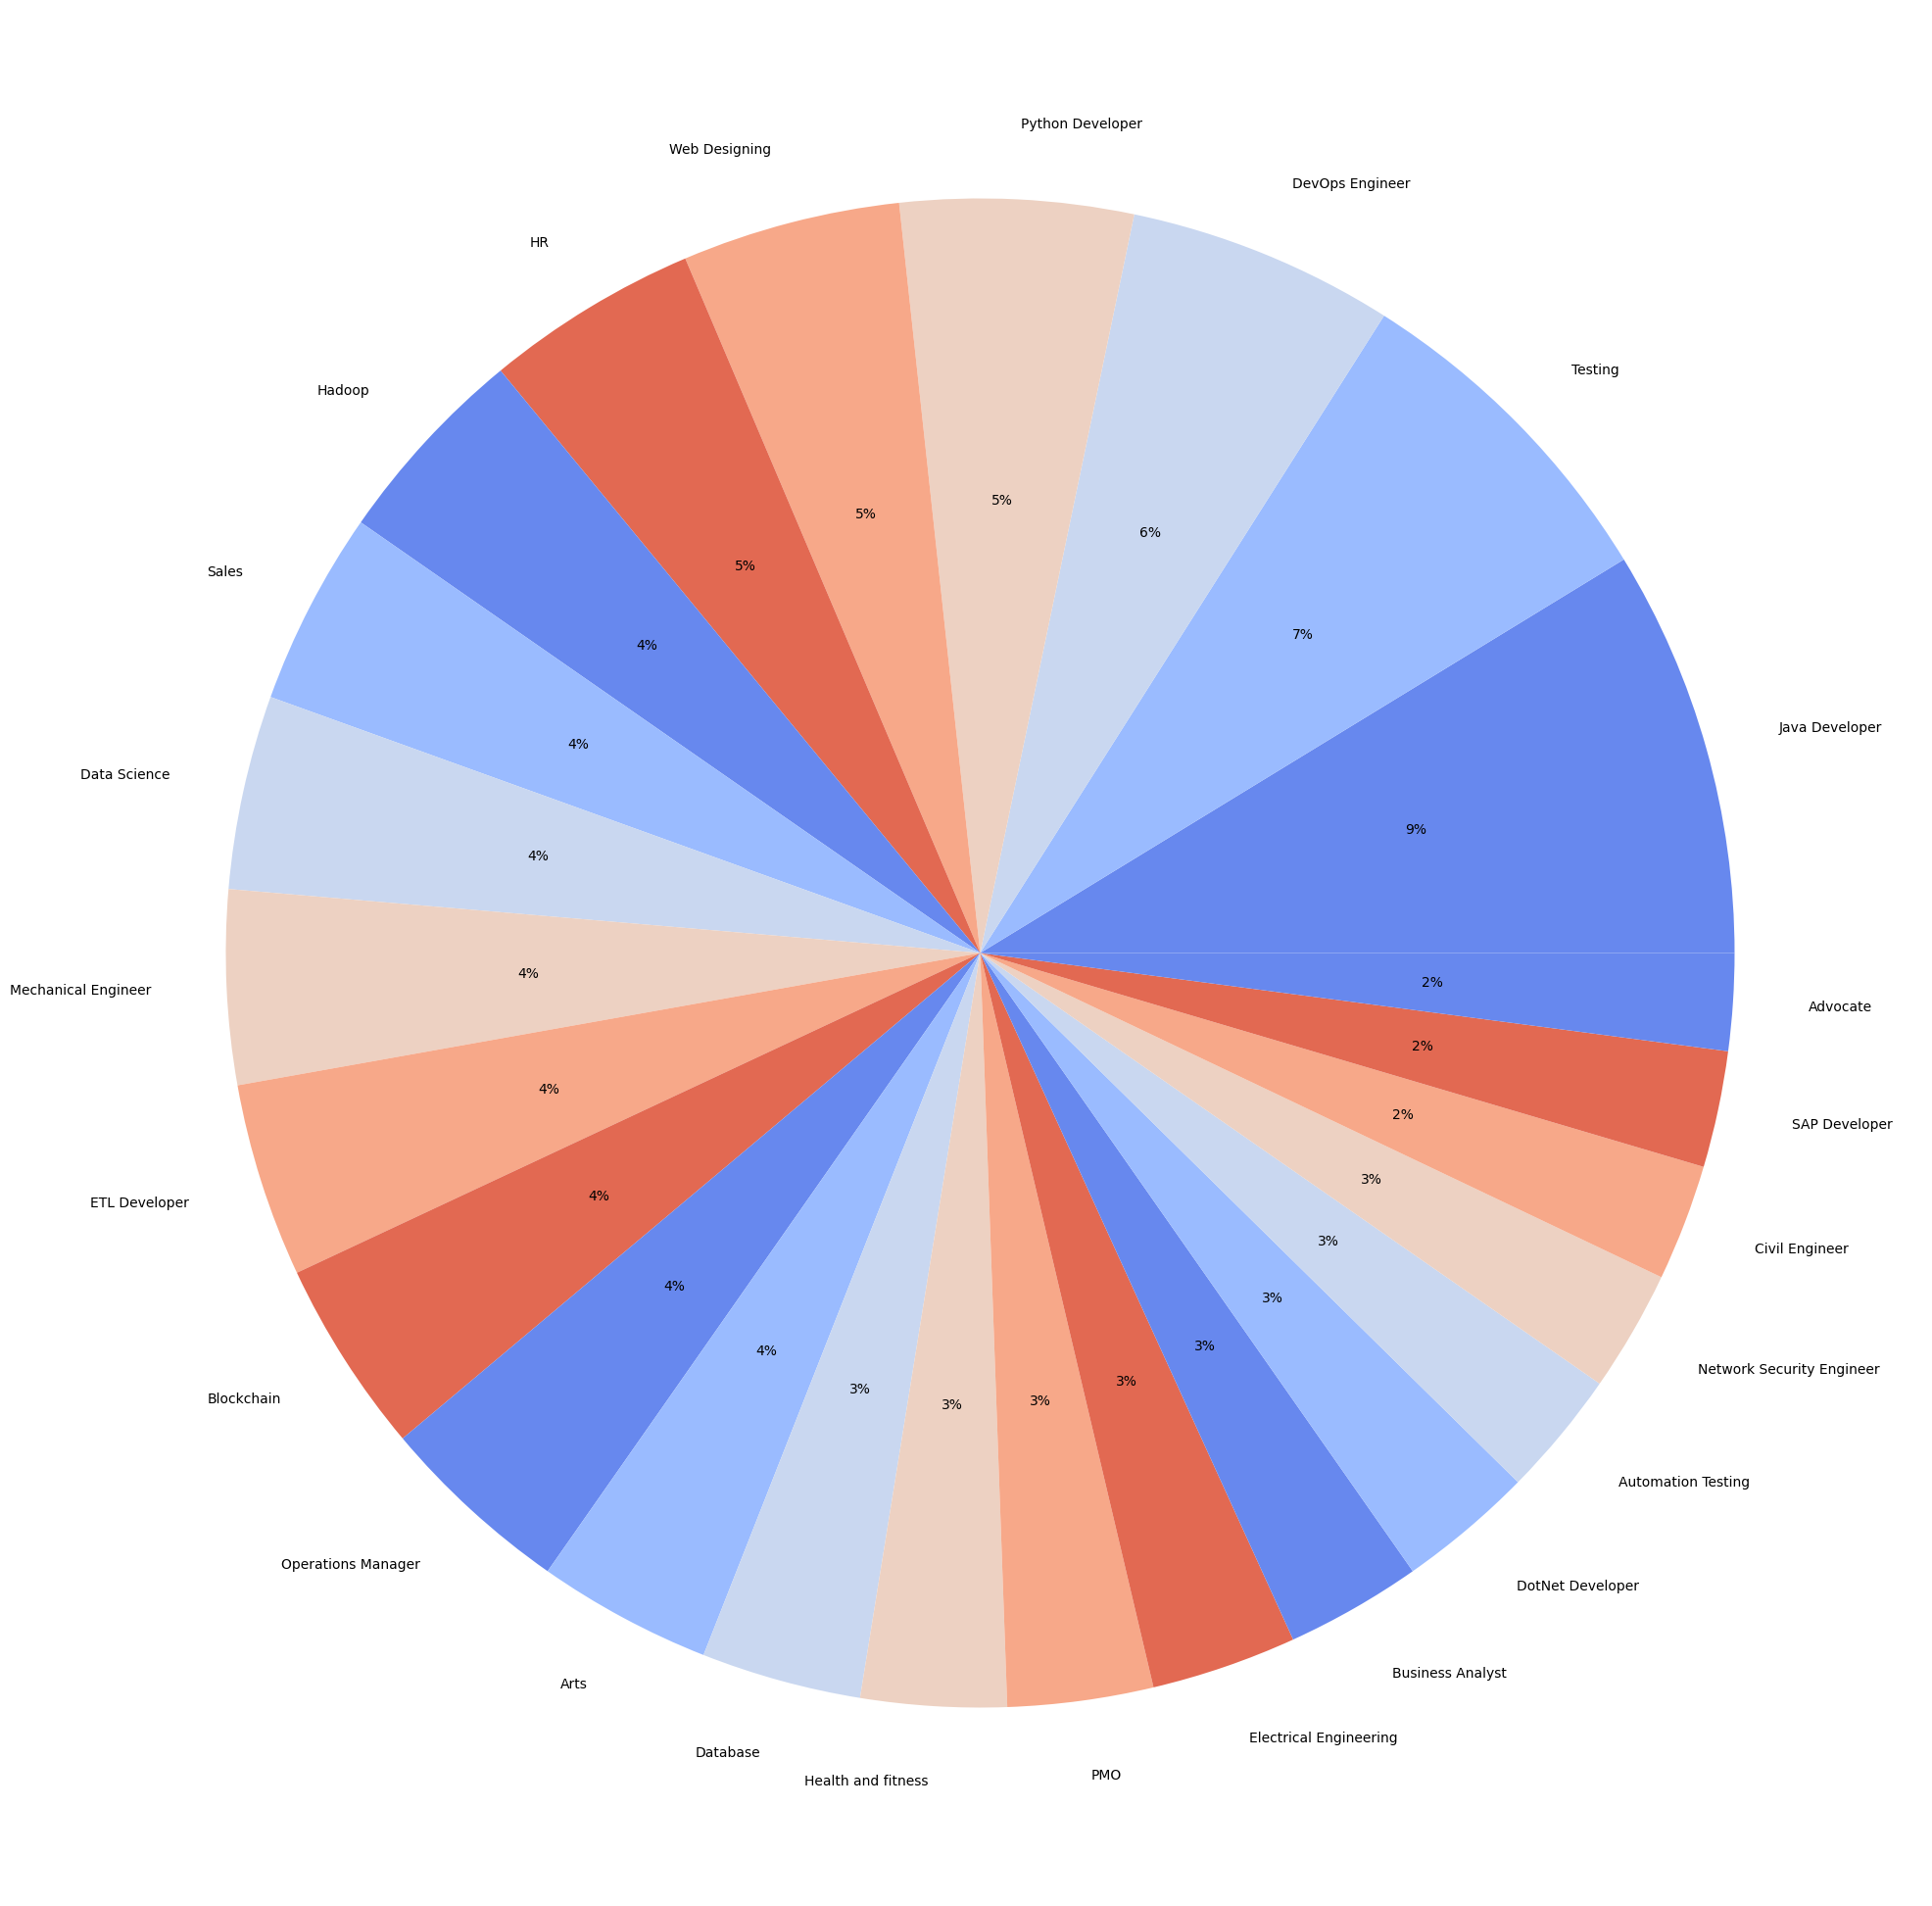

In [10]:
targetCounts = df['Category'].value_counts()
targetLabels  = targetCounts.index
# Make square figures and axes
plt.figure(1, figsize=(25,25))
the_grid = GridSpec(2, 2)



palette_color = sns.color_palette('coolwarm')

# plotting data on chart
plt.pie(targetCounts, labels=targetLabels, colors=palette_color, autopct='%.0f%%')

# displaying chart
plt.show()

**Exercise 5: Convert all the `Resume` text to lower case and remove trailing spaces [0.5 Mark]**




In [11]:
# Convert all characters to lowercase and remove trailing spaces
# YOUR CODE HERE
df['Resume'] = df['Resume'].str.lower().str.strip()

In [12]:
df['Resume'].head()

,Resume
0,skills * programming languages: python (pandas...
1,education details \r\nmay 2013 to may 2017 b.e...
2,"areas of interest deep learning, control syste..."
3,skills â¢ r â¢ python â¢ sap hana â¢ table...
4,"education details \r\n mca ymcaust, faridab..."


### Cleaning Resume

**Exercise 6: Define a function to clean the resume text [2 Mark]**

In the text there are special characters, urls, hashtags, mentions, etc. You need to remove for the following:  

* URLs: For reference click [here](https://stackoverflow.com/questions/11331982/how-to-remove-any-url-within-a-string-in-python)
* RT | cc: For reference click [here](https://www.machinelearningplus.com/python/python-regex-tutorial-examples/)
* Hashtags, # and Mentions, @
* punctuations
* extra whitespace

PS: Use the provided reference similarly for removing any other such elements.

After cleaning as above, store the Resume Text in a separate column (New Feature say `Cleaned_Resume`).


In [13]:
import re



def cleanResume(resumeText):
    """
    Clean the input text by removing URLs, emails, special characters, and stop words.

    :param text: The string to be cleaned
    :return: The cleaned string
    """

    # Compile patterns for URLs and emails to speed up cleaning process
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    email_pattern = re.compile(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b')

    # Remove URLs
    clean_text = url_pattern.sub('', resumeText)

    # Remove emails
    clean_text = email_pattern.sub('', resumeText)

    # Remove special characters (keeping only words and whitespace)
    clean_text = re.sub(r'[^\w\s]', '', clean_text)

    # Remove stop words by filtering the split words of the text
    stop_words = set(stopwords.words('english'))
    clean_text = ' '.join(word for word in clean_text.split() if word.lower() not in stop_words)

    return clean_text

In [14]:
# Apply the function defined above and save the
df["Cleaned_Resume"] = df["Resume"].apply(lambda x: cleanResume(x))

In [15]:
df["Resume"][0]

'skills * programming languages: python (pandas, numpy, scipy, scikit-learn, matplotlib), sql, java, javascript/jquery. * machine learning: regression, svm, naã¯ve bayes, knn, random forest, decision trees, boosting techniques, cluster analysis, word embedding, sentiment analysis, natural language processing, dimensionality reduction, topic modelling (lda, nmf), pca & neural nets. * database visualizations: mysql, sqlserver, cassandra, hbase, elasticsearch d3.js, dc.js, plotly, kibana, matplotlib, ggplot, tableau. * others: regular expression, html, css, angular 6, logstash, kafka, python flask, git, docker, computer vision - open cv and understanding of deep learning.education details \r\n\r\ndata science assurance associate \r\n\r\ndata science assurance associate - ernst & young llp\r\nskill details \r\njavascript- exprience - 24 months\r\njquery- exprience - 24 months\r\npython- exprience - 24 monthscompany details \r\ncompany - ernst & young llp\r\ndescription - fraud investigatio

In [16]:
df["Cleaned_Resume"][0]

'skills programming languages python pandas numpy scipy scikitlearn matplotlib sql java javascriptjquery machine learning regression svm naãve bayes knn random forest decision trees boosting techniques cluster analysis word embedding sentiment analysis natural language processing dimensionality reduction topic modelling lda nmf pca neural nets database visualizations mysql sqlserver cassandra hbase elasticsearch d3js dcjs plotly kibana matplotlib ggplot tableau others regular expression html css angular 6 logstash kafka python flask git docker computer vision open cv understanding deep learningeducation details data science assurance associate data science assurance associate ernst young llp skill details javascript exprience 24 months jquery exprience 24 months python exprience 24 monthscompany details company ernst young llp description fraud investigations dispute services assurance technology assisted review tar technology assisted review assists accelerating review process run ana

**Exercise 7: Convert the categorical variable `Category` to a numerical feature and make a different column <font color="#990000">`label`</font>, which can be treated as the target variable [0.5 Mark]**

**Hint:** Use [`sklearn.preprocessing.LabelEncoder()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) method

In [17]:
from sklearn.preprocessing import LabelEncoder

# YOUR CODE HERE



# Initialize the Label Encoder
le = LabelEncoder()

# Fit the label encoder on the 'Category' column to learn the unique categories
le.fit(df["Category"])

# Transform the 'Category' column into encoded numerical values
df["Label"] = le.transform(df["Category"])

In [18]:
df['Category'].value_counts()

,count
Category,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
Sales,40
Data Science,40


In [19]:
df['Label'].value_counts()

,count
Label,
15,84
23,70
8,55
20,48
24,45
12,44
13,42
22,40
6,40


In [20]:
df.Label.unique()

array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

**Exercise 8: Plot the histogram of words count of `Cleaned_Resume` text [0.5 Mark]**

**Hint:** Use sns.distplot()

In [21]:
from collections import Counter
import string

df['Count'] = df['Cleaned_Resume'].apply(lambda x: len(x.split()))

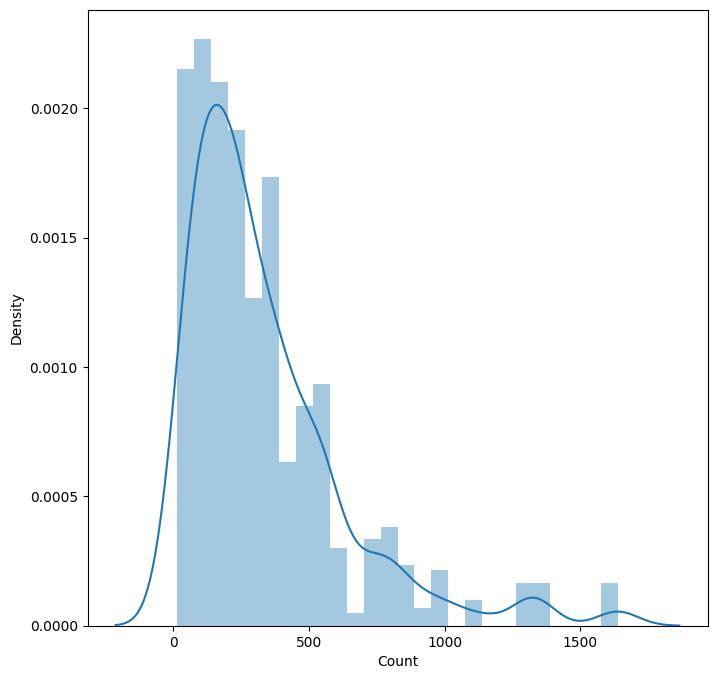

In [22]:
plt.figure(figsize= (8, 8))

# YOUR CODE HERE
df['Count'] = df['Cleaned_Resume'].apply(lambda x: len(x.split()))
sns.distplot(df['Count'])

plt.show()

### Train Test Split

**Exercise 9: Split the dataset into training, validation, and testing set [0.5 Mark]**

* Do stratified splitting using `label` column

In [23]:
df.columns

Index(['Category', 'Resume', 'Cleaned_Resume', 'Label', 'Count'], dtype='object')

In [24]:
X = df['Cleaned_Resume']
y = df['Label']

In [25]:
df_new = df[['Cleaned_Resume', 'Label']]

In [26]:
train_test_df, val_df = train_test_split(df_new, test_size=0.2, random_state=42, stratify=df[['Label']])
train_df, test_df = train_test_split(train_test_df, test_size=0.2, random_state=42, stratify=train_test_df[['Label']])

print(len(train_df), len(val_df), len(test_df))



615 193 154


In [27]:
train_df['Label'].value_counts().sort_index() / len(train_df)



,count
Label,
0,0.021138
1,0.037398
2,0.027642
3,0.042276
4,0.029268
5,0.024390
6,0.042276
7,0.034146
8,0.056911


In [28]:
val_df['Label'].value_counts().sort_index() / len(val_df)


,count
Label,
0,0.020725
1,0.036269
2,0.025907
3,0.041451
4,0.031088
5,0.025907
6,0.041451
7,0.036269
8,0.056995


In [29]:
test_df['Label'].value_counts().sort_index() / len(test_df)

,count
Label,
0,0.019481
1,0.038961
2,0.025974
3,0.038961
4,0.025974
5,0.025974
6,0.038961
7,0.032468
8,0.058442


### Convert to HuggingFace Dataset

**Exercise 10: Convert Pandas dataframe to HuggingFace Dataset [1 Mark]**

**Hint:**

    import pandas as pd
    from datasets import Dataset, DatasetDict

    tdf = pd.DataFrame({"a": [1, 2, 3], "b": ['hello', 'ola', 'thammi']})
    vdf = pd.DataFrame({"a": [4, 5, 6], "b": ['four', 'five', 'six']})
    tds = Dataset.from_pandas(tdf)
    vds = Dataset.from_pandas(vdf)

    ds = DatasetDict()

    ds['train'] = tds
    ds['validation'] = vds

    print(ds)

In [30]:
from datasets import Dataset, DatasetDict

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

ds = DatasetDict()

ds['train'] = train_ds
ds['validation'] = val_ds
ds['test'] = test_ds

### Tokenizer

**Exercise 11: Load tokenizer for checkpoint `distilbert-base-uncased` [0.5 Mark]**

**Hint:** `AutoTokenizer`

In [31]:
# Load tokenizer
checkpoint='distilbert-base-uncased' # Different Bert models are there.
tokenizer = AutoTokenizer.from_pretrained(checkpoint)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [32]:
def tokenize_fn(batch):
  return tokenizer(batch['Cleaned_Resume'],truncation=True)

In [33]:
tokenized_datasets = ds.map(tokenize_fn, batched=True)
tokenized_datasets

Map:   0%|          | 0/615 [00:00<?, ? examples/s]

Map:   0%|          | 0/193 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Cleaned_Resume', 'Label', '__index_level_0__', 'input_ids', 'attention_mask'],
        num_rows: 615
    })
    validation: Dataset({
        features: ['Cleaned_Resume', 'Label', '__index_level_0__', 'input_ids', 'attention_mask'],
        num_rows: 193
    })
    test: Dataset({
        features: ['Cleaned_Resume', 'Label', '__index_level_0__', 'input_ids', 'attention_mask'],
        num_rows: 154
    })
})

### Load Pre-Trained Model

**Exercise 12: Load pre-trained Bert model with checkpoint `distilbert-base-uncased` and show model summary [0.5 Mark]**

**Hint:** `AutoModelForSequenceClassification`

In [34]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint,num_labels=25)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Exercise 13: Freeze/Un-Freeze different layers  [0.5 Mark]**

**Hint:** Freeze layers starting with name *distilbert*


In [35]:
# Display layers name
for name, param in model.named_parameters():
  print(name)
# YOUR CODE HERE

distilbert.embeddings.word_embeddings.weight
distilbert.embeddings.position_embeddings.weight
distilbert.embeddings.LayerNorm.weight
distilbert.embeddings.LayerNorm.bias
distilbert.transformer.layer.0.attention.q_lin.weight
distilbert.transformer.layer.0.attention.q_lin.bias
distilbert.transformer.layer.0.attention.k_lin.weight
distilbert.transformer.layer.0.attention.k_lin.bias
distilbert.transformer.layer.0.attention.v_lin.weight
distilbert.transformer.layer.0.attention.v_lin.bias
distilbert.transformer.layer.0.attention.out_lin.weight
distilbert.transformer.layer.0.attention.out_lin.bias
distilbert.transformer.layer.0.sa_layer_norm.weight
distilbert.transformer.layer.0.sa_layer_norm.bias
distilbert.transformer.layer.0.ffn.lin1.weight
distilbert.transformer.layer.0.ffn.lin1.bias
distilbert.transformer.layer.0.ffn.lin2.weight
distilbert.transformer.layer.0.ffn.lin2.bias
distilbert.transformer.layer.0.output_layer_norm.weight
distilbert.transformer.layer.0.output_layer_norm.bias
distil

In [36]:
# Freezing
# Freezing
for name, param in model.named_parameters():
     if name.startswith("distilbert"): # choose whatever you like here
        param.requires_grad = False


In [37]:
# Display layers gradient
# Displaying of layers gradient
for name, param in model.named_parameters():
     print(name, param.requires_grad)

distilbert.embeddings.word_embeddings.weight False
distilbert.embeddings.position_embeddings.weight False
distilbert.embeddings.LayerNorm.weight False
distilbert.embeddings.LayerNorm.bias False
distilbert.transformer.layer.0.attention.q_lin.weight False
distilbert.transformer.layer.0.attention.q_lin.bias False
distilbert.transformer.layer.0.attention.k_lin.weight False
distilbert.transformer.layer.0.attention.k_lin.bias False
distilbert.transformer.layer.0.attention.v_lin.weight False
distilbert.transformer.layer.0.attention.v_lin.bias False
distilbert.transformer.layer.0.attention.out_lin.weight False
distilbert.transformer.layer.0.attention.out_lin.bias False
distilbert.transformer.layer.0.sa_layer_norm.weight False
distilbert.transformer.layer.0.sa_layer_norm.bias False
distilbert.transformer.layer.0.ffn.lin1.weight False
distilbert.transformer.layer.0.ffn.lin1.bias False
distilbert.transformer.layer.0.ffn.lin2.weight False
distilbert.transformer.layer.0.ffn.lin2.bias False
distilbe

### Metrics

In [38]:
from datasets import load_metric
metric = load_metric("glue", "sst2")         # Type 'Y' when prompted

The repository for glue contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/glue.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


In [39]:
metric.compute(predictions=[1,0,1], references=[1,0,0])

{'accuracy': 0.6666666666666666}

In [40]:
def compute_metrics(logits_and_labels):
    logits, labels = logits_and_labels
    predictions = np.argmax(logits,axis=-1)
    return metric.compute(predictions=predictions,references=labels)


**Exercise 14: Fine-tune model on train dataset  [0.5 Mark]**
 * Create `TrainingArguments` class object
 * Create `Trainer` class  object
 * Train it for higher number of epochs say 40 or 50
 * Switch to GPU runtime if needed

**Hint:** Check if the training code is running without any error with CPU runtime, later switch to GPU runtime for faster training. Once trained, save the model, create its zip file, and download into your system.

In [41]:
from transformers import TrainingArguments
from transformers import Trainer

In [42]:
# Set up the training arguments

model_output_path = "/content/bert_model"

training_args = TrainingArguments(
    model_output_path, #  directory where the trained model will be saved,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    num_train_epochs=40

)

In [43]:
# Train the model

trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset = tokenized_datasets["validation"],
    tokenizer =tokenizer,
    compute_metrics=compute_metrics

)

### Save Model

In [44]:
# Save the model
trainer.save_model('saved_bert_model')

In [45]:
!ls

bert_model  sample_data  saved_bert_model  UpdatedResumeDataSet.csv


In [46]:
# Create a Zip file and download
!zip -r saved_bert_model.zip saved_bert_model

  adding: saved_bert_model/ (stored 0%)
  adding: saved_bert_model/tokenizer_config.json (deflated 76%)
  adding: saved_bert_model/vocab.txt (deflated 53%)
  adding: saved_bert_model/config.json (deflated 64%)
  adding: saved_bert_model/tokenizer.json (deflated 71%)
  adding: saved_bert_model/training_args.bin (deflated 51%)
  adding: saved_bert_model/model.safetensors (deflated 8%)
  adding: saved_bert_model/special_tokens_map.json (deflated 42%)


### Load Model

**Exercise 15: Load the saved model and create a pipeline to perform text classification [1 Mark]**

 * Create the pipeline object for text classification
 * Create a `make_prediction` function to use pipeline object and output the prediction label

**Hint:** pipeline()

In [47]:
from transformers import pipeline

In [48]:

my_model = pipeline(
    'text-classification',
    model='saved_bert_model')

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [49]:
my_model('programming, web designing, coding')[0]['label']

'LABEL_8'

In [50]:
# Function to predict label for a resume text

def make_prediction(input_text):
    return my_model(input_text)[0]['label']


In [51]:
# Test prediction
make_prediction('programming, web designing, coding')

'LABEL_8'

In [52]:
make_prediction('continuous integration and continuous delivery')

'LABEL_8'

In [53]:
make_prediction('law student and journalist')

'LABEL_8'

In [54]:
make_prediction('machine learning, data, EDA, big data, neural networks')

'LABEL_6'

In [84]:
val_df['Cleaned_Resume_Short'] = val_df['Cleaned_Resume'].str.slice(0,511)

In [85]:
val_df["label_pred"] = val_df.apply(lambda x: make_prediction(x['Cleaned_Resume_Short']), axis=1)

In [88]:
val_df['label_pred'] = val_df['label_pred'].str.slice(6,)

In [89]:
val_df

,Cleaned_Resume,Label,Cleaned_Resume_Short,label_pred
337,education details january 2013 master engineer...,15,education details january 2013 master engineer...,14
581,technical skills responsibilities â hands expe...,20,technical skills responsibilities â hands expe...,14
218,education details june 2014 june 2018 mechanic...,16,education details june 2014 june 2018 mechanic...,14
819,technical summary â knowledge informatica powe...,10,technical summary â knowledge informatica powe...,14
276,education details may 2014 diploma nutrition e...,14,education details may 2014 diploma nutrition e...,14
...,...,...,...,...
957,computer skills â proficient ms office word ba...,23,computer skills â proficient ms office word ba...,14
518,education details august 2000 electronics pune...,18,education details august 2000 electronics pune...,14
48,training special education certificate course ...,12,training special education certificate course ...,14
483,â achievement oriented people management skill...,11,â achievement oriented people management skill...,14


In [90]:
metric.compute(predictions=val_df["label_pred"], references=val_df['Label'])

{'accuracy': 0.031088082901554404}

## **Optional**: Create a Gradio based web interface to test and display the model predictions

In [55]:
!pip -q install gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 189.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 12.5 MB/s eta 0:00:00


In [56]:
import gradio

In [57]:
# Textbox to take Input from user
in_text = gradio.Textbox(lines=10, placeholder=None, value="Enter resume text here", label='Resume Text')


# Textbox to display Output prediction
out_label = gradio.Textbox(type="text", label='Predicted Class Label')


# Gradio interface to create UI
iface = gradio.Interface(fn = make_prediction,             # fine-tuned model is used inside this function
                         inputs = [in_text],
                         outputs = [out_label],
                         title = "Resume Classification",
                         description = "Using fine-tuned Bert model",
                         allow_flagging = 'never')


# Launch interface
iface.launch(share = True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://2aaf0cda622e2ba40c.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
